Device: cuda

Loading stages 1–8 …
  Stage 1: 187 nodes, 782 edges
  Stage 2: 194 nodes, 995 edges
  Stage 3: 198 nodes, 990 edges
  Stage 4: 204 nodes, 1193 edges
  Stage 5: 211 nodes, 1561 edges
  Stage 6: 216 nodes, 1540 edges
  Stage 7: 222 nodes, 2133 edges
  Stage 8: 219 nodes, 2061 edges

Extracting node features …
  Stage 1: feature matrix (187, 4)
  Stage 2: feature matrix (194, 4)
  Stage 3: feature matrix (198, 4)
  Stage 4: feature matrix (204, 4)
  Stage 5: feature matrix (211, 4)
  Stage 6: feature matrix (216, 4)
  Stage 7: feature matrix (222, 4)
  Stage 8: feature matrix (219, 4)

Held-out stage: 4
Training stages: [1, 2, 3, 5, 6, 7, 8]

Pre-training GAT encoder (700 epochs) …
  Epoch   0  avg loss 5.5322
  Epoch  50  avg loss 1.7123
  Epoch 100  avg loss 1.5535
  Epoch 150  avg loss 1.4765
  Epoch 200  avg loss 1.4300
  Epoch 250  avg loss 1.3880
  Epoch 300  avg loss 1.3891
  Epoch 350  avg loss 1.3413
  Epoch 400  avg loss 1.2925
  Epoch 450  avg loss 1.3210
  Epoch

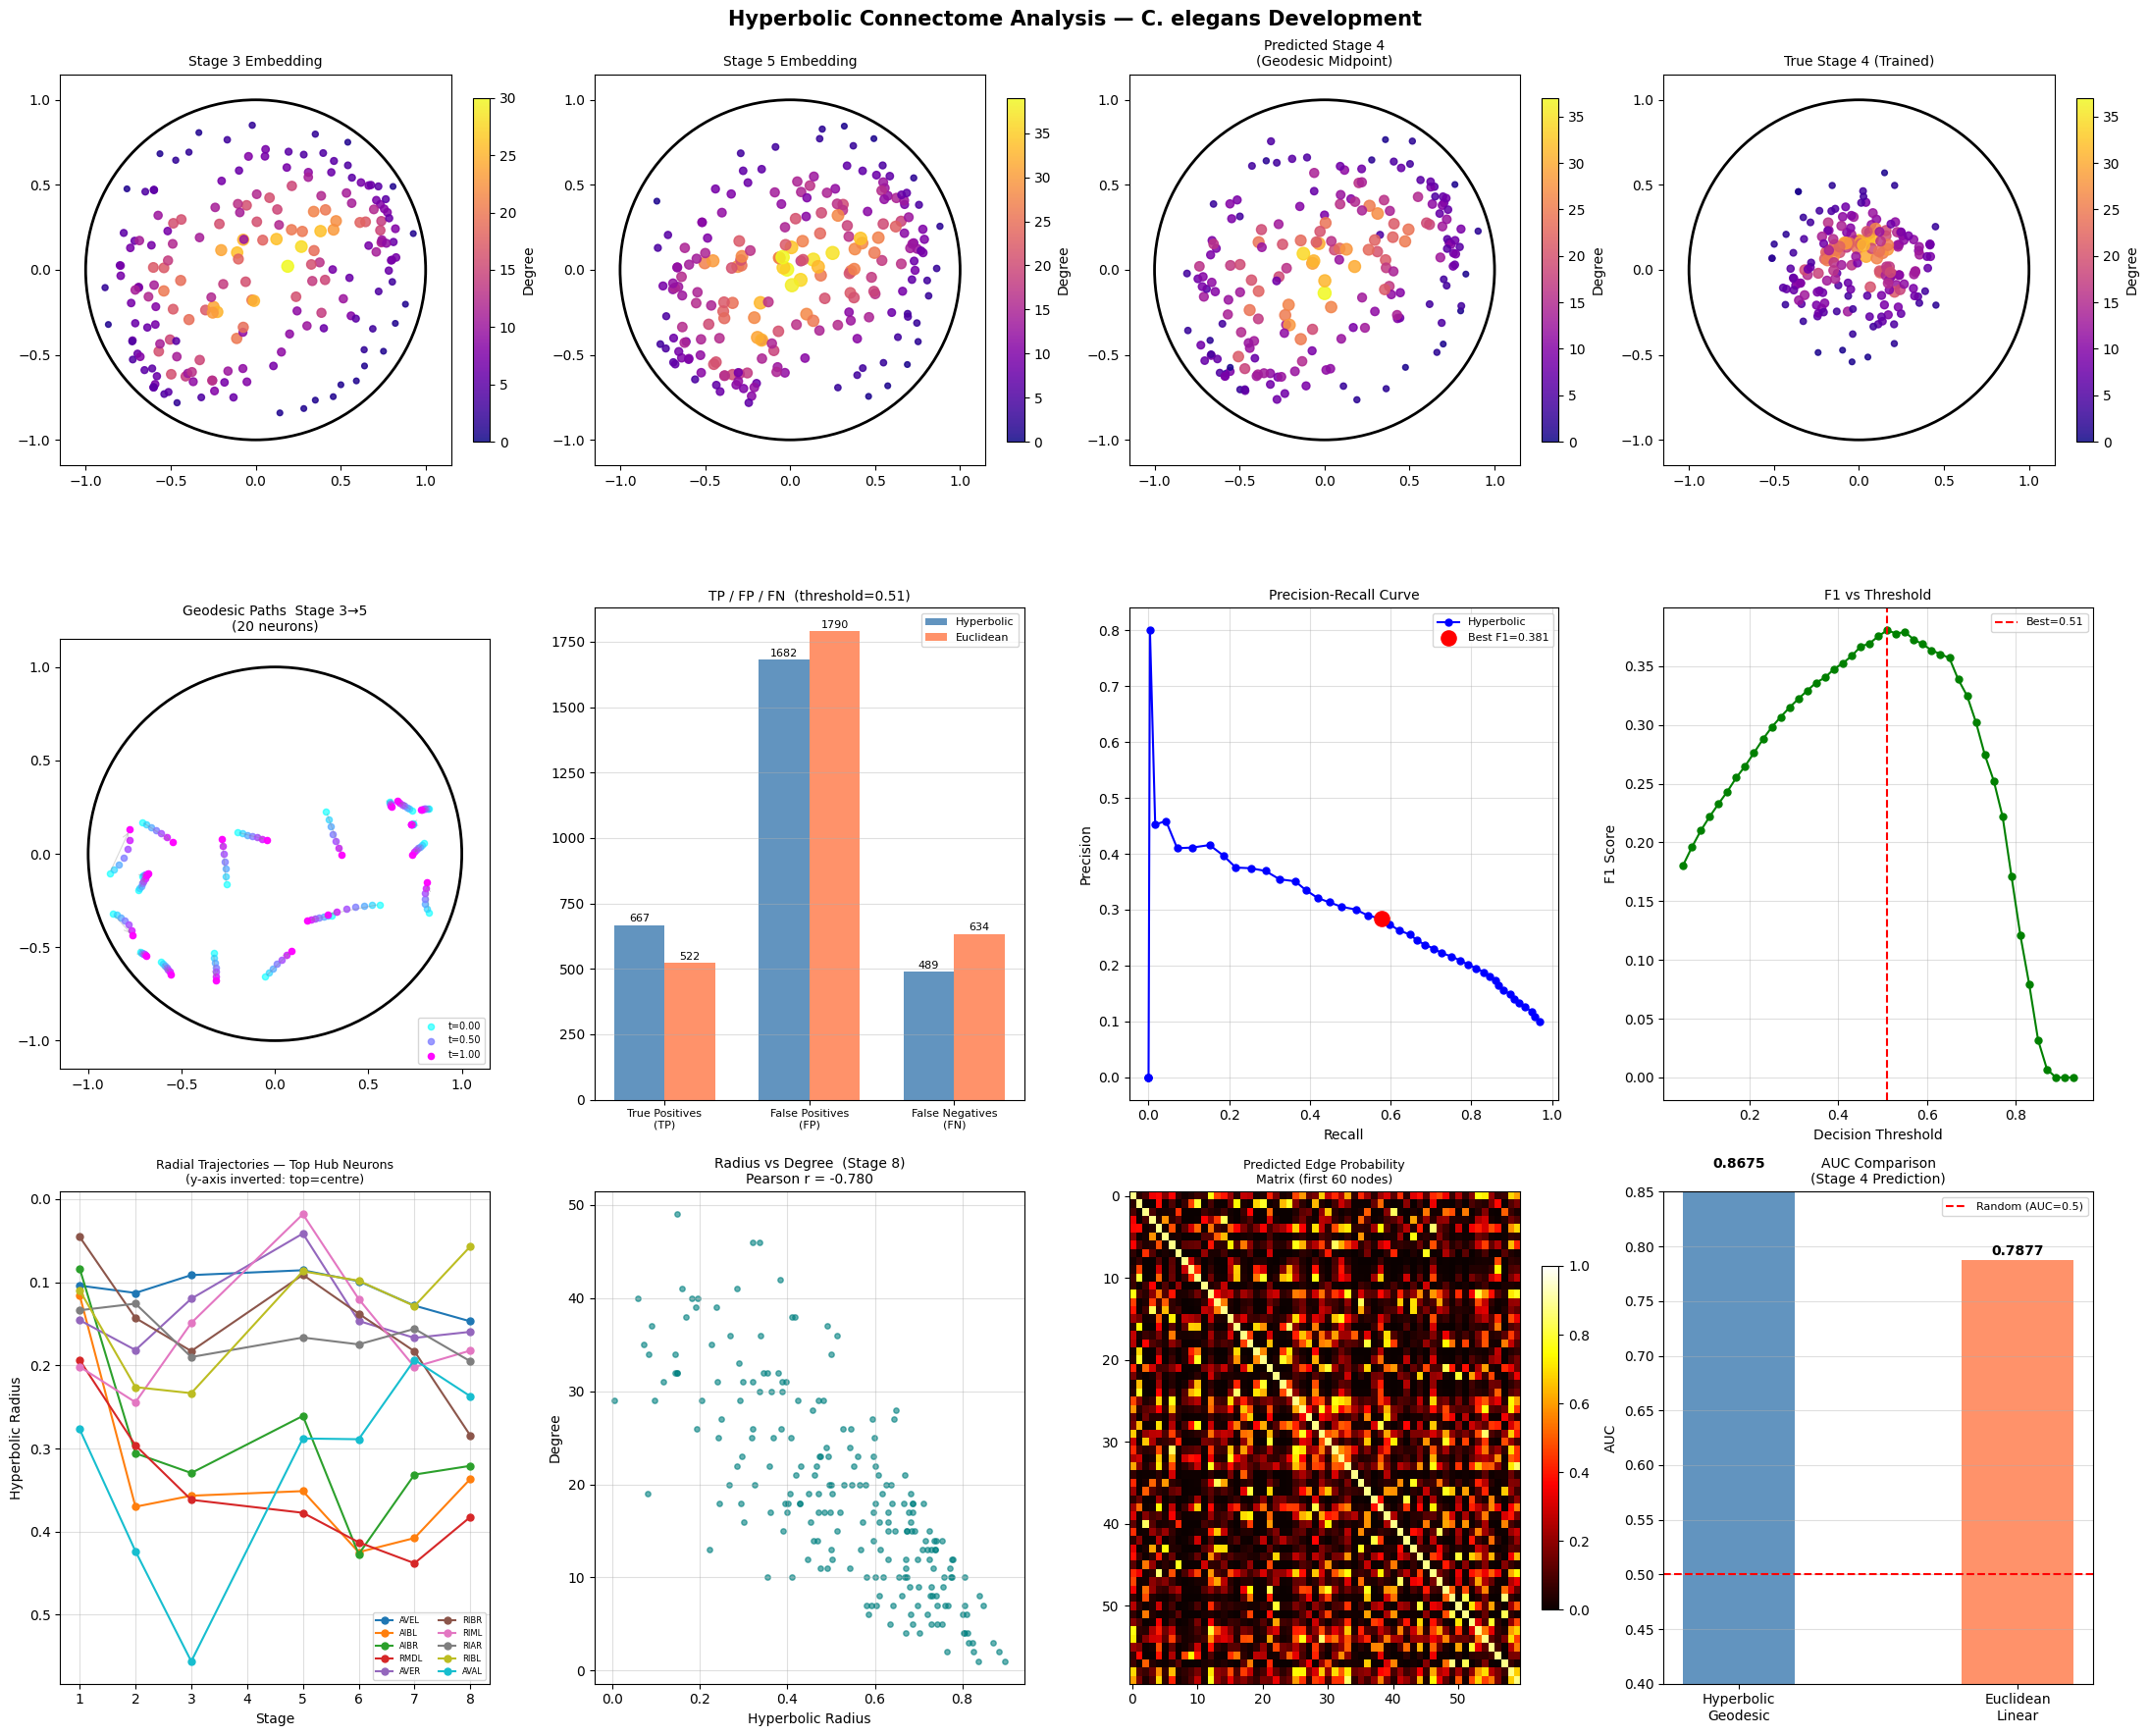


══════════════════════════════════════════════════════════════
  FINAL RESULTS — STAGE 4 PREDICTION FROM STAGES 3 & 5
══════════════════════════════════════════════════════════════
  Common nodes evaluated : 195
  True edges in stage 4  : 1157
  Decision threshold      : 0.51

  Metric                   Hyperbolic    Euclidean
  ──────────────────────────────────────────────
  AUC                          0.8675       0.7877
  True Positives                  667          522
  False Positives                1682         1790
  False Negatives                 489          634
  True Negatives                16077        15969
  Precision                    0.2840       0.2258
  Recall                       0.5770       0.4516
  F1 Score                     0.3806       0.3010
══════════════════════════════════════════════════════════════

WHAT DOES EACH METRIC TELL US?
───────────────────────────────
AUC   > 0.5  → model ranks true edges above non-edges better than random.
            

In [ ]:
"""
HYPERBOLIC CONNECTOME ANALYSIS PIPELINE
========================================
Full pipeline from raw Excel files to TP/FP/FN evaluation.

Mathematical Journey:
  1. Graphs         → node features (degree, clustering, betweenness)
  2. GAT            → enrich features using neighborhood structure
  3. Poincaré Ball  → embed nodes in hyperbolic space
  4. Fermi-Dirac    → decode edge probabilities from hyperbolic distances
  5. Geodesics      → interpolate between stage embeddings
  6. Hold-out       → predict stage 4, compare to ground truth

Held-out experiment:
  Train on stages 1,2,3,5,6,7,8
  Interpolate stage 3 <-> stage 5 at t=0.5 to predict stage 4
  Evaluate TP/FP/FN against true stage 4 connectome
"""

# ─────────────────────────────────────────────
# SECTION 0 — INSTALL & IMPORTS
# ─────────────────────────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["geoopt", "networkx", "openpyxl"]:
    install(pkg)

import os, random, warnings
import numpy as np
import pandas as pd
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import geoopt
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ─────────────────────────────────────────────
# SECTION 1 — LOAD DATA
# ─────────────────────────────────────────────
# Each Excel file is one developmental stage of the C. elegans connectome.
# Columns: pre (sender neuron), post (receiver neuron), synapses (count).

def load_stage(stage: int) -> nx.Graph:
    """
    Load one developmental stage into an undirected graph.

    Why undirected?
    A synapse from A→B and B→A are often measured separately.
    For connectivity structure we treat the channel as bilateral.
    Edges keep a 'weight' attribute = total synapse count.
    """
    filepath = f"witvliet_2020_{stage}.xlsx"
    df = pd.read_excel(filepath)

    G = nx.DiGraph()
    for _, row in df.iterrows():
        pre, post, w = str(row["pre"]), str(row["post"]), float(row["synapses"])
        if G.has_edge(pre, post):
            G[pre][post]["weight"] += w
        else:
            G.add_edge(pre, post, weight=w)

    G = G.to_undirected()

    # Keep only the largest connected component.
    # Isolated neurons (no synapses in this stage) cannot be embedded.
    if not nx.is_connected(G):
        G = G.subgraph(
            max(nx.connected_components(G), key=len)
        ).copy()

    return G

print("\nLoading stages 1–8 …")
graphs = {}
for s in range(1, 9):
    graphs[s] = load_stage(s)
    print(f"  Stage {s}: {graphs[s].number_of_nodes()} nodes, "
          f"{graphs[s].number_of_edges()} edges")


# ─────────────────────────────────────────────
# SECTION 2 — NODE FEATURE EXTRACTION
# ─────────────────────────────────────────────
# We compute four scalar features per neuron per stage.
#
# Feature 1 – Degree k_i
#   k_i = number of direct neighbours
#   Why? Hubs embed near the Poincaré origin; peripheral nodes near the boundary.
#
# Feature 2 – log(k_i + 1)  (log-degree)
#   Many brain networks follow a power-law degree distribution P(k) ~ k^{-γ}.
#   Taking log linearises this distribution, making gradients better behaved.
#
# Feature 3 – Clustering coefficient C_i
#   C_i = (triangles through i) / (k_i*(k_i-1)/2)
#   Measures "how cliquish" a neuron's neighbourhood is.
#   High C_i → locally dense module.
#
# Feature 4 – Betweenness centrality b_i
#   b_i = Σ_{s≠i≠t} σ(s,t|i) / σ(s,t)
#   σ(s,t|i) = shortest paths s→t through i; σ(s,t) = all shortest s→t paths.
#   High b_i → neuron is a bridge/bottleneck in the network.

def extract_features(G: nx.Graph):
    """Return (node_list, feature_matrix [N×4])."""
    nodes = list(G.nodes())
    N = len(nodes)

    deg      = dict(G.degree())
    clust    = nx.clustering(G)
    # Approximate betweenness (exact is O(VE)); k=100 random pivots is enough
    between  = nx.betweenness_centrality(G, normalized=True,
                                         k=min(100, N))

    max_deg  = max(deg.values()) + 1e-9
    max_bet  = max(between.values()) + 1e-9

    F_mat = np.array([
        [
            deg[n] / max_deg,                              # normalised degree
            np.log(deg[n] + 1) / np.log(max_deg + 1),     # normalised log-degree
            clust[n],                                       # clustering ∈ [0,1]
            between[n] / max_bet,                          # normalised betweenness
        ]
        for n in nodes
    ], dtype=np.float32)

    return nodes, F_mat

print("\nExtracting node features …")
stage_features = {}   # stage → {"nodes": [...], "feat": ndarray}
for s in range(1, 9):
    nodes, feat = extract_features(graphs[s])
    stage_features[s] = {"nodes": nodes, "feat": feat}
    print(f"  Stage {s}: feature matrix {feat.shape}")


# ─────────────────────────────────────────────
# SECTION 3 — ADJACENCY BUILDER
# ─────────────────────────────────────────────

def build_adj(G: nx.Graph, nodes: list) -> torch.Tensor:
    """
    Build a float32 adjacency tensor A ∈ {0,1}^{N×N}
    for the given ordered node list.
    """
    n   = len(nodes)
    idx = {node: i for i, node in enumerate(nodes)}
    A   = np.zeros((n, n), dtype=np.float32)

    for u, v in G.edges():
        if u in idx and v in idx:
            i, j = idx[u], idx[v]
            A[i, j] = A[j, i] = 1.0

    return torch.tensor(A)


# ─────────────────────────────────────────────
# SECTION 4 — GRAPH ATTENTION NETWORK (GAT)
# ─────────────────────────────────────────────
#
# Standard GCN averages neighbours uniformly:
#   h_i' = σ( W · mean_{j∈N(i)} h_j )
#
# This ignores that some neighbours are more informative than others.
#
# Graph Attention Network (Veličković et al. 2018) learns per-edge weights:
#
#   e_ij = LeakyReLU( a^T · [W·h_i ‖ W·h_j] )   ← raw score
#
#   α_ij = softmax_j(e_ij) = exp(e_ij) / Σ_k exp(e_ik)  ← normalised weight
#
#   h_i' = ELU( Σ_{j∈N(i)} α_ij · W·h_j )             ← weighted aggregation
#
# Intuition: a^T is a small learnable vector; the dot product with the
# concatenated transformed features gives how "compatible" h_i and h_j are.
# Softmax forces the weights to sum to 1 over each node's neighbourhood.

class GATLayer(nn.Module):
    """One graph attention layer."""
    def __init__(self, in_dim: int, out_dim: int, dropout: float = 0.1):
        super().__init__()
        # W: shared linear projection of node features before attention
        self.W   = nn.Linear(in_dim, out_dim, bias=False)
        # a: the attention vector (projects concatenated pair to scalar)
        self.a   = nn.Linear(2 * out_dim, 1, bias=False)
        self.lrelu   = nn.LeakyReLU(negative_slope=0.2)
        self.dropout = nn.Dropout(dropout)

    def forward(self, X: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
        """
        X : (N, in_dim)
        A : (N, N)  adjacency (0/1)
        returns : (N, out_dim)
        """
        N  = X.size(0)
        Wh = self.W(X)                              # (N, out_dim)

        # ── Expand for all pairs (i, j) ──
        Wh_i = Wh.unsqueeze(1).expand(N, N, -1)    # (N, N, out_dim)
        Wh_j = Wh.unsqueeze(0).expand(N, N, -1)    # (N, N, out_dim)
        pair = torch.cat([Wh_i, Wh_j], dim=-1)      # (N, N, 2·out_dim)

        # ── Raw attention scores ──
        e = self.lrelu(self.a(pair).squeeze(-1))    # (N, N)

        # ── Mask non-edges to -∞ so softmax → 0 for them ──
        e = e.masked_fill(A == 0, float("-inf"))

        # ── Normalise: α_ij = softmax over j ──
        alpha = F.softmax(e, dim=1)                 # (N, N)
        # Guard against NaN rows (nodes with no neighbours)
        alpha = torch.where(torch.isnan(alpha),
                            torch.zeros_like(alpha), alpha)
        alpha = self.dropout(alpha)

        # ── Aggregate: h_i' = Σ_j α_ij · W·h_j ──
        out = torch.mm(alpha, Wh)                   # (N, out_dim)
        return F.elu(out)


class GATEncoder(nn.Module):
    """
    Two-layer GAT that maps raw node features (4-dim) to
    an 8-dim enriched representation h_i per node.

    The enriched h_i captures not just a neuron's own properties
    but also the structural context of its neighbourhood.
    """
    def __init__(self, in_dim=4, hidden=16, out_dim=8):
        super().__init__()
        self.layer1 = GATLayer(in_dim,  hidden)
        self.layer2 = GATLayer(hidden,  out_dim)
        # Linear map to propose an initial 2-D position in Poincaré ball
        self.init_proj = nn.Linear(out_dim, 2)

    def forward(self, X: torch.Tensor, A: torch.Tensor):
        """returns h (N, out_dim),  init_pos (N, 2)"""
        h  = self.layer1(X, A)
        h  = self.layer2(h, A)
        p  = torch.tanh(self.init_proj(h)) * 0.3   # keep inside ball
        return h, p


# ─────────────────────────────────────────────
# SECTION 5 — HYPERBOLIC EMBEDDING
# ─────────────────────────────────────────────
#
# Poincaré Ball Model  B^n_c  =  { x ∈ R^n : c·‖x‖² < 1 }
#
# The key property: volumes grow EXPONENTIALLY with radius.
#   Vol(ball of radius r) ~ exp((n-1)·√c·r)
#
# This matches the exponential number of nodes at distance d in a tree.
# So hierarchical / scale-free graphs embed naturally in hyperbolic space
# with much less distortion than in Euclidean space.
#
# ── Fermi-Dirac Decoder ──
#
# We decode edge probability from hyperbolic distance d_ij :
#
#   P(edge | i,j) = 1 / ( exp((d_ij − r) / T) + 1 )
#
#   r ∈ R  learned threshold distance
#   T > 0  learned temperature
#
# Intuition:
#   • If d_ij ≪ r  →  P ≈ 1   (close pairs are almost certainly connected)
#   • If d_ij ≫ r  →  P ≈ 0   (distant pairs are almost certainly not)
#   • T controls how sharp the transition is
#
# Why not exp(-d) used previously?
#   • exp(-d) ∈ (0,1] but is always 1 when d=0 (self-loops get score 1)
#   • No learnable threshold → can't adapt to the network's density
#   • Saturates to 0 quickly; gradients die for distant pairs
#
# Loss: Binary Cross-Entropy  (correct for binary edge labels)
#   L = - (1/|pairs|) Σ_{i<j} [ A_ij log P_ij + (1−A_ij) log(1−P_ij) ]
#
# Why not MSE?
#   MSE assumes Gaussian noise around the target.
#   Edges are Bernoulli random variables → BCE is the correct likelihood.

class HyperbolicEmbedder(nn.Module):
    """
    Learnable node positions z_i on the Poincaré ball B^2_c.
    Fermi-Dirac decoder with learnable r and T.
    """
    def __init__(self, n_nodes: int, curvature: float = 1.0):
        super().__init__()
        self.manifold = geoopt.PoincareBall(c=curvature)

        # z: positions on the manifold — use ManifoldParameter so
        # Riemannian Adam knows these live on a curved space
        self.z = geoopt.ManifoldParameter(
            torch.randn(n_nodes, 2) * 0.01,
            manifold=self.manifold
        )
        # Fermi-Dirac parameters (ordinary Euclidean scalars)
        self.r = nn.Parameter(torch.tensor(0.5))
        self.T = nn.Parameter(torch.tensor(0.3))

    # ── forward: compute pairwise probabilities ──
    def forward(self):
        """Returns P (N,N) edge probs and D (N,N) hyperbolic distances."""
        # Pairwise distance: manifold.dist expects (..., dim)
        D = self.manifold.dist(
            self.z.unsqueeze(1),   # (N, 1, 2)
            self.z.unsqueeze(0)    # (1, N, 2)
        )                          # → (N, N)

        T = self.T.clamp(min=0.01)
        P = 1.0 / (torch.exp((D - self.r) / T) + 1.0)
        return P, D

    def radii(self) -> torch.Tensor:
        """Euclidean norms inside the ball = 'hyperbolic radius'."""
        return torch.norm(self.z.detach(), dim=1)


# ─────────────────────────────────────────────
# SECTION 6 — PROCRUSTES ALIGNMENT
# ─────────────────────────────────────────────
#
# The Poincaré ball is isometric under Möbius transformations.
# Rotations are a subset: rotating all points doesn't change any distance.
#
# Consequence: embedding stage t and embedding stage t+1 independently
# can place them at arbitrary relative angles.  Before comparing radii
# or doing geometric interpolation we must align them.
#
# Procrustes problem:
#   Find orthogonal R* = argmin_R ‖Z_target − Z_source · R^T‖²_F
#
# Closed-form solution via SVD:
#   M = Z_source^T · Z_target     (2×2 cross-covariance)
#   M = U S V^T                   (SVD)
#   R* = V · U^T
#
# This is a pure rotation (det = +1); we enforce it below.

def procrustes_align(z_source: torch.Tensor,
                     z_target: torch.Tensor) -> torch.Tensor:
    """
    Rotate z_source onto z_target (both N×2).
    Returns z_source rotated.
    """
    M = z_source.T @ z_target          # (2, 2)
    U, _S, Vt = torch.linalg.svd(M)
    # Ensure proper rotation (not reflection): det(R) should be +1
    d = torch.det(Vt.T @ U.T)
    D_fix = torch.diag(torch.tensor([1.0, d], device=z_source.device))
    R = Vt.T @ D_fix @ U.T             # (2, 2) rotation matrix
    return z_source @ R.T


# ─────────────────────────────────────────────
# SECTION 7 — PRE-TRAIN GAT ENCODER
# ─────────────────────────────────────────────
# We pre-train the GAT with a self-supervised objective:
# predict the adjacency from dot-product similarities of node embeddings.
# This teaches the GAT to separate connected vs disconnected neurons
# before the hyperbolic stage even begins.

HELD_OUT = 4
TRAIN_STAGES = [s for s in range(1, 9) if s != HELD_OUT]

print(f"\nHeld-out stage: {HELD_OUT}")
print(f"Training stages: {TRAIN_STAGES}")

gat = GATEncoder(in_dim=4, hidden=64, out_dim=16).to(DEVICE)
gat_opt = optim.Adam(gat.parameters(), lr=0.001, weight_decay=1e-4)

print("\nPre-training GAT encoder (700 epochs) …")
for ep in range(700):
    gat.train()
    ep_loss = 0.0
    for s in TRAIN_STAGES:
        G_s   = graphs[s]
        nodes = stage_features[s]["nodes"]
        feat  = stage_features[s]["feat"]
        A     = build_adj(G_s, nodes).to(DEVICE)
        X     = torch.tensor(feat).to(DEVICE)

        gat_opt.zero_grad()
        h, _ = gat(X, A)

        # Self-supervised: h_i · h_j  predicts whether i–j is an edge
        # (cosine-style similarity, then sigmoid)
        h_norm = F.normalize(h, dim=1)
        sim    = (h_norm @ h_norm.T).clamp(-1+1e-6, 1-1e-6)
        # Map [-1,1] → [0,1]
        sim_01 = (sim + 1.0) / 2.0
        sim_01 = sim_01.clamp(1e-6, 1-1e-6)
        n_pos_g = A.sum().clamp(min=1)
        n_neg_g = A.numel() - n_pos_g
        w_g     = (n_neg_g / n_pos_g).clamp(max=5.0)
        wmat_g  = torch.where(A == 1,
                      torch.full_like(A, w_g.item()), torch.ones_like(A))
        loss = F.binary_cross_entropy(sim_01, A, weight=wmat_g)

        loss.backward()
        gat_opt.step()
        ep_loss += loss.item()

    if ep % 50 == 0:
        print(f"  Epoch {ep:3d}  avg loss {ep_loss/len(TRAIN_STAGES):.4f}")

# Freeze GAT — we use it only for feature enrichment now
for p in gat.parameters():
    p.requires_grad_(False)
gat.eval()
print("GAT frozen.")


# ─────────────────────────────────────────────
# SECTION 8 — TRAIN HYPERBOLIC EMBEDDINGS
# ─────────────────────────────────────────────
#
# For each training stage s:
#   1. Get enriched features h from frozen GAT
#   2. Initialise z on Poincaré ball
#      • Stage 1: use GAT's proposed positions (scaled small)
#      • Stage s>1: warm-start from previous stage's aligned embedding
#   3. Optimise with Riemannian Adam
#      Standard Adam does gradient descent in R^n (flat space).
#      Riemannian Adam corrects for the manifold curvature by:
#       - computing gradients in the tangent space at z
#       - doing the update step in the tangent space
#       - mapping back to the manifold with the exponential map
#   4. After training, Procrustes-align to previous stage

def train_one_stage(G, nodes, feat, epochs=600, z_init=None):
    """Train hyperbolic embedding for one stage. Returns HyperbolicEmbedder."""
    n = len(nodes)
    A = build_adj(G, nodes).to(DEVICE)
    X = torch.tensor(feat).to(DEVICE)

    # ── Get GAT-enriched features ──
    with torch.no_grad():
        _h, gat_pos = gat(X, A)   # gat_pos: proposed initial 2-D positions

    # ── Create embedder ──
    emb = HyperbolicEmbedder(n).to(DEVICE)

    with torch.no_grad():
        if z_init is None:
            # Use GAT-proposed positions (already small via tanh*0.3)
            emb.z.data = emb.manifold.projx(gat_pos)
        else:
            emb.z.data = emb.manifold.projx(z_init.to(DEVICE))

    # ── Riemannian Adam ──
    # z lives on manifold → use geoopt; r and T live in R → also fine
    opt = geoopt.optim.RiemannianAdam(
        [{"params": [emb.z]},
         {"params": [emb.r, emb.T], "lr": 0.005}],
        lr=0.01
    )

    emb.train()
    for ep in range(epochs):
        opt.zero_grad()
        P, _D = emb()
        P_safe = P.clamp(1e-6, 1-1e-6)
        # Weight positive edges by ratio of negatives to positives
        n_pos = A.sum().clamp(min=1)
        n_neg = A.numel() - n_pos
        pos_weight_val = (n_neg / n_pos).clamp(max=5.0)  # cap at 20x to avoid instability
        weight_mat = torch.where(A == 1,
                        torch.full_like(A, pos_weight_val.item()),
                        torch.ones_like(A))
        loss_bce = F.binary_cross_entropy(P_safe, A, weight=weight_mat)

        # Repulsion: non-edge pairs should have distance > 0.5
        # F.relu(0.5 - d) = 0 if already far enough, positive if too close
        non_edge_dists = _D[A == 0]
        repulsion = F.relu(0.5 - non_edge_dists).mean()

        loss = loss_bce + 0.2 * repulsion
        loss.backward()
        opt.step()

    emb.eval()
    return emb


print(f"\nTraining hyperbolic embeddings for stages {TRAIN_STAGES} …")
stage_embs   = {}   # stage → HyperbolicEmbedder
stage_nodes_ = {}   # stage → node list (same order used in emb.z)
prev_emb     = None
prev_nodes   = None

for s in TRAIN_STAGES:
    print(f"  Stage {s} …", end=" ", flush=True)
    G     = graphs[s]
    nodes = stage_features[s]["nodes"]
    feat  = stage_features[s]["feat"]

    # ── Warm start from previous stage ──
    z_init = None
    if prev_emb is not None:
        n_curr = len(nodes)
        z_warm = torch.randn(n_curr, 2) * 0.01

        common = [n for n in nodes if n in prev_nodes]
        if len(common) > 3:
            ip = [prev_nodes.index(n) for n in common]
            ic = [nodes.index(n)      for n in common]
            z_warm[ic] = prev_emb.z.detach().cpu()[ip]

        z_init = z_warm

    emb = train_one_stage(G, nodes, feat, epochs=600, z_init=z_init)

    # ── Procrustes align to previous stage ──
    if prev_emb is not None:
        common = [n for n in nodes if n in prev_nodes]
        if len(common) > 3:
            ip  = [prev_nodes.index(n) for n in common]
            ic  = [nodes.index(n)      for n in common]

            z_curr_cpu = emb.z.detach().cpu()
            z_prev_cpu = prev_emb.z.detach().cpu()

            z_src  = z_curr_cpu[ic]   # current stage, common nodes
            z_tgt  = z_prev_cpu[ip]   # previous stage, common nodes

            R_mat  = z_src.T @ z_tgt
            U2, _, Vt2 = torch.linalg.svd(R_mat)
            d2     = torch.det(Vt2.T @ U2.T)
            D2     = torch.diag(torch.tensor([1.0, d2.item()]))
            R_opt  = Vt2.T @ D2 @ U2.T

            z_aligned = (z_curr_cpu @ R_opt.T)
            with torch.no_grad():
                emb.z.data = emb.manifold.projx(z_aligned.to(DEVICE))

    stage_embs[s]   = emb
    stage_nodes_[s] = nodes
    prev_emb  = emb
    prev_nodes = nodes

    r_avg = emb.radii().mean().item()
    print(f"done  (mean radius {r_avg:.3f})")

print("All training stages embedded.")
# Diagnostic: check embedding spread
for s in TRAIN_STAGES:
    z_s = stage_embs[s].z.detach().cpu()
    D_s = manifold_cpu.dist(z_s.unsqueeze(1), z_s.unsqueeze(0))
    mask_d = torch.triu(torch.ones_like(D_s, dtype=torch.bool), diagonal=1)
    d_vals = D_s[mask_d]
    print(f"  Stage {s} | mean dist={d_vals.mean():.3f}  "
          f"std={d_vals.std():.3f}  "
          f"r={stage_embs[s].r.item():.3f}  "
          f"T={stage_embs[s].T.item():.3f}")

# ─────────────────────────────────────────────
# SECTION 9 — GEODESIC INTERPOLATION
# ─────────────────────────────────────────────
#
# Goal: given embeddings z_A (stage 3) and z_B (stage 5),
#       predict z_mid (stage 4) using the *geometric midpoint*
#       of the hyperbolic geodesic.
#
# In Riemannian geometry, the geodesic from x to y is:
#
#   γ(t) = exp_x( t · log_x(y) )        t ∈ [0,1]
#
# where:
#   log_x(y)  Logarithmic map: maps y into the tangent space T_x M.
#             Think of it as "the direction and distance from x to y,
#             expressed as a flat vector attached at x".
#   exp_x(v)  Exponential map: starts at x, follows the geodesic in
#             direction v for ‖v‖ units, lands on the manifold.
#
# At t=0 : γ(0) = exp_x(0) = x         ✓
# At t=1 : γ(1) = exp_x(log_x(y)) = y  ✓  (exp and log are inverses)
# At t=0.5 : midpoint on the geodesic  ← what we use
#
# Why not Euclidean midpoint?
#   Linear interpolation 0.5*(z_A+z_B) can land OUTSIDE the Poincaré ball,
#   or at a point that violates the metric geometry.
#   The geodesic midpoint always stays on the manifold and respects curvature.

manifold_cpu = geoopt.PoincareBall(c=1.0)   # CPU manifold for inference


def geodesic_midpoint(manifold, z_A: torch.Tensor,
                       z_B: torch.Tensor, t: float = 0.5) -> torch.Tensor:
    """
    Point at parameter t along geodesic from z_A to z_B.

    z_A, z_B : (N, 2) on Poincaré ball
    returns   : (N, 2) interpolated positions
    """
    log_v = manifold.logmap(z_A, z_B)      # tangent vector at z_A → z_B
    z_mid = manifold.expmap(z_A, t * log_v) # follow geodesic for t steps
    z_mid = manifold.projx(z_mid)           # numerical projection into ball
    return z_mid


# ── Identify nodes common to stages 3, 4, 5 ──
nodes3 = stage_nodes_[3]
nodes5 = stage_nodes_[5]
nodes4_true = stage_features[HELD_OUT]["nodes"]   # ground truth node list

common_345 = list(
    set(nodes3) & set(nodes5) & set(nodes4_true)
)
print(f"\nCommon nodes across stages 3, 4, 5: {len(common_345)}")

i3  = [nodes3.index(n)      for n in common_345]
i5  = [nodes5.index(n)      for n in common_345]
i4t = [nodes4_true.index(n) for n in common_345]

# Extract aligned embeddings
z3_cpu = stage_embs[3].z.detach().cpu()[i3]
z5_cpu = stage_embs[5].z.detach().cpu()[i5]

# Predict stage 4
z4_pred = geodesic_midpoint(manifold_cpu, z3_cpu, z5_cpu, t=0.5)
print(f"Predicted embedding shape: {z4_pred.shape}")


# ─────────────────────────────────────────────
# SECTION 10 — EVALUATION (TP / FP / FN)
# ─────────────────────────────────────────────
#
# From predicted positions we decode edge probabilities via Fermi-Dirac,
# then threshold to obtain a binary prediction matrix.
#
# Confusion matrix for a pair (i,j) with i<j:
#
#             Predicted 1   Predicted 0
#   True  1 │     TP             FN
#   True  0 │     FP             TN
#
# Precision  = TP / (TP + FP)   → "how reliable are our positive calls?"
# Recall     = TP / (TP + FN)   → "how many real edges did we recover?"
# F1         = 2·P·R / (P+R)   → harmonic mean of Precision and Recall
# AUC        = threshold-free rank measure (0.5 = random, 1.0 = perfect)

# Build ground-truth adjacency for the common nodes in stage 4
A4_full    = build_adj(graphs[HELD_OUT], nodes4_true).numpy()
A4_common  = A4_full[np.ix_(i4t, i4t)]   # restrict to common nodes


def evaluate(z_pred: torch.Tensor,
             A_true: np.ndarray,
             r_fd: float = 1.0,
             T_fd: float = 0.5,
             threshold: float = 0.5):
    """
    Decode edge probs from z_pred, return full evaluation dict.
    Uses upper-triangular pairs only (undirected, no self-loops).
    """
    N = z_pred.shape[0]

    # Pairwise hyperbolic distances
    D = manifold_cpu.dist(
        z_pred.unsqueeze(1),
        z_pred.unsqueeze(0)
    ).detach().numpy()

    # Fermi-Dirac probabilities
    P = 1.0 / (np.exp((D - r_fd) / T_fd) + 1.0)

    # Upper-triangular mask (each pair counted once)
    mask   = np.triu(np.ones((N, N), dtype=bool), k=1)
    y_true = A_true[mask].astype(int)
    y_prob = P[mask]
    y_pred = (y_prob >= threshold).astype(int)

    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())
    TN = int(((y_pred == 0) & (y_true == 0)).sum())

    precision = TP / (TP + FP + 1e-9)
    recall    = TP / (TP + FN + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    auc       = roc_auc_score(y_true, y_prob)

    return dict(TP=TP, FP=FP, FN=FN, TN=TN,
                precision=precision, recall=recall,
                f1=f1, auc=auc,
                y_true=y_true, y_prob=y_prob,
                D=D, P_mat=P)


# ── Scan thresholds to find the one with highest F1 ──
print("\nScanning decision thresholds for Hyperbolic model …")
thresh_results = []
# Average the learned r and T from the two bracketing stages
r_learned = ((stage_embs[3].r + stage_embs[5].r) / 2).item()
T_learned = ((stage_embs[3].T + stage_embs[5].T) / 2).item()
print(f"  Learned r={r_learned:.3f}, T={T_learned:.3f}")

thresh_results = []   # ← must exist before the loop
for thr in np.arange(0.05, 0.95, 0.02):
    res = evaluate(z4_pred, A4_common,
                   r_fd=r_learned, T_fd=T_learned, threshold=thr)
    thresh_results.append({"threshold": round(thr, 2), **res})
best_hyp = max(thresh_results, key=lambda x: x["f1"])
print(f"  Best threshold {best_hyp['threshold']:.2f}  "
      f"F1={best_hyp['f1']:.4f}")


# ── Euclidean baseline ──
# Same interpolation idea but in flat Euclidean space.
# Linear midpoint: z_mid = 0.5*(z_A + z_B)
# Distance: standard L2 ‖z_i - z_j‖
# Why compare?  To isolate the benefit of hyperbolic geometry.

def train_euclidean(G, nodes, epochs=600, z_init=None):
    """Flat-space embedding with Fermi-Dirac decoder + BCE loss."""
    n  = len(nodes)
    A  = build_adj(G, nodes).to(DEVICE)
    z  = nn.Parameter(
        torch.randn(n, 2, device=DEVICE) * 0.01
        if z_init is None else z_init.to(DEVICE).clone().detach()
    )
    r = nn.Parameter(torch.tensor(1.0, device=DEVICE))
    T = nn.Parameter(torch.tensor(0.5, device=DEVICE))
    opt = optim.Adam([z, r, T], lr=0.01)

    for _ in range(epochs):
        opt.zero_grad()
        D   = torch.cdist(z, z)
        P   = 1.0 / (torch.exp((D - r) / T.clamp(0.01)) + 1.0)
        loss = F.binary_cross_entropy(P.clamp(1e-6, 1-1e-6), A)
        loss.backward()
        opt.step()

    return z.detach().cpu()

print("\nTraining Euclidean embeddings for stages 3 and 5 …")
z3_e = train_euclidean(graphs[3], nodes3)
# warm start stage 5 from stage 3
z5_e_init = torch.randn(len(nodes5), 2) * 0.01
common_35 = [n for n in nodes5 if n in nodes3]
for n in common_35:
    z5_e_init[nodes5.index(n)] = z3_e[nodes3.index(n)]
z5_e = train_euclidean(graphs[5], nodes5, z_init=z5_e_init)

z3_e_common = z3_e[i3]
z5_e_common = z5_e[i5]
z4_e_mid    = 0.5 * (z3_e_common + z5_e_common)   # flat midpoint

def evaluate_euclidean(z_pred, A_true, threshold=0.5):
    """Euclidean Fermi-Dirac evaluation."""
    D = torch.cdist(z_pred, z_pred).numpy()
    P = 1.0 / (np.exp((D - 1.0) / 0.5) + 1.0)
    mask   = np.triu(np.ones_like(A_true, dtype=bool), k=1)
    y_true = A_true[mask].astype(int)
    y_prob = P[mask]
    y_pred = (y_prob >= threshold).astype(int)
    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())
    TN = int(((y_pred == 0) & (y_true == 0)).sum())
    precision = TP / (TP + FP + 1e-9)
    recall    = TP / (TP + FN + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    auc       = roc_auc_score(y_true, y_prob)
    return dict(TP=TP, FP=FP, FN=FN, TN=TN,
                precision=precision, recall=recall, f1=f1, auc=auc,
                y_true=y_true, y_prob=y_prob)

euc_results = []   # ← this line was missing
for thr in np.arange(0.05, 0.95, 0.02):
    res_e = evaluate_euclidean(z4_e_mid, A4_common, threshold=thr)
    euc_results.append({"threshold": round(thr, 2), **res_e})
best_euc = max(euc_results, key=lambda x: x["f1"])


# ─────────────────────────────────────────────
# SECTION 11 — RADIAL TRAJECTORIES
# ─────────────────────────────────────────────
# One of the key findings from the PDF: hub neurons (high degree) sit
# near the Poincaré origin (small radius), and their radius decreases
# as they gain more connections during development.

G8      = graphs[8]
deg8    = dict(G8.degree())
top10   = sorted(deg8, key=deg8.get, reverse=True)[:10]

print(f"\nTop 10 hubs in stage 8: {top10}")

hub_trajectories = {hub: {} for hub in top10}
for s in TRAIN_STAGES:
    nodes_s = stage_nodes_[s]
    radii_s = stage_embs[s].radii().cpu().numpy()
    for hub in top10:
        if hub in nodes_s:
            hub_trajectories[hub][s] = radii_s[nodes_s.index(hub)]


# ─────────────────────────────────────────────
# SECTION 12 — ALL PLOTS
# ─────────────────────────────────────────────

fig = plt.figure(figsize=(22, 18))
fig.suptitle("Hyperbolic Connectome Analysis — C. elegans Development",
             fontsize=15, fontweight='bold')

# Helper: draw Poincaré disk boundary
def poincare_circle(ax):
    c = plt.Circle((0, 0), 1, fill=False, color='black', lw=2)
    ax.add_artist(c)
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)
    ax.set_aspect('equal')

# ── Plot 1: Stage 3 embedding ──
ax1 = fig.add_subplot(3, 4, 1)
poincare_circle(ax1)
z3_np  = stage_embs[3].z.detach().cpu().numpy()
deg3_v = np.array([graphs[3].degree(n) for n in nodes3])
sc = ax1.scatter(z3_np[:,0], z3_np[:,1], c=deg3_v,
                  cmap='plasma', s=15+2*deg3_v, alpha=0.85, vmin=0)
plt.colorbar(sc, ax=ax1, fraction=0.04, label='Degree')
ax1.set_title('Stage 3 Embedding', fontsize=10)

# ── Plot 2: Stage 5 embedding ──
ax2 = fig.add_subplot(3, 4, 2)
poincare_circle(ax2)
z5_np  = stage_embs[5].z.detach().cpu().numpy()
deg5_v = np.array([graphs[5].degree(n) for n in nodes5])
sc = ax2.scatter(z5_np[:,0], z5_np[:,1], c=deg5_v,
                  cmap='plasma', s=15+2*deg5_v, alpha=0.85, vmin=0)
plt.colorbar(sc, ax=ax2, fraction=0.04, label='Degree')
ax2.set_title('Stage 5 Embedding', fontsize=10)

# ── Plot 3: Predicted stage 4 (geodesic midpoint) ──
ax3 = fig.add_subplot(3, 4, 3)
poincare_circle(ax3)
z4_pred_np = z4_pred.detach().numpy()
deg4_v     = np.array([graphs[HELD_OUT].degree(n) for n in common_345])
sc = ax3.scatter(z4_pred_np[:,0], z4_pred_np[:,1], c=deg4_v,
                  cmap='plasma', s=15+2*deg4_v, alpha=0.85, vmin=0)
plt.colorbar(sc, ax=ax3, fraction=0.04, label='Degree')
ax3.set_title(f'Predicted Stage {HELD_OUT}\n(Geodesic Midpoint)', fontsize=10)

# ── Plot 4: True stage 4 ──
ax4 = fig.add_subplot(3, 4, 4)
poincare_circle(ax4)
# Train stage 4 for visualisation ONLY (not used in evaluation)
feat4  = stage_features[HELD_OUT]["feat"]
emb4_viz = train_one_stage(graphs[HELD_OUT], nodes4_true, feat4, epochs=400)
z4_true_np = emb4_viz.z.detach().cpu().numpy()
i4c        = [nodes4_true.index(n) for n in common_345]
sc = ax4.scatter(z4_true_np[i4c,0], z4_true_np[i4c,1], c=deg4_v,
                  cmap='plasma', s=15+2*deg4_v, alpha=0.85, vmin=0)
plt.colorbar(sc, ax=ax4, fraction=0.04, label='Degree')
ax4.set_title(f'True Stage {HELD_OUT} (Trained)', fontsize=10)

# ── Plot 5: Geodesic paths for 20 sample neurons ──
ax5 = fig.add_subplot(3, 4, 5)
poincare_circle(ax5)
samp_idx = list(range(0, min(20, len(common_345))))
z3_s = z3_cpu[samp_idx]
z5_s = z5_cpu[samp_idx]

colors_t = cm.cool(np.linspace(0, 1, 7))
for ti, t_val in enumerate(np.linspace(0, 1, 7)):
    z_t  = geodesic_midpoint(manifold_cpu, z3_s, z5_s, t=t_val)
    z_np = z_t.detach().numpy()
    ax5.scatter(z_np[:,0], z_np[:,1], s=20,
                color=colors_t[ti], alpha=0.6 + 0.06*ti,
                label=f't={t_val:.2f}' if ti in [0, 3, 6] else None)

# Draw arrows from stage 3 to stage 5
for i in samp_idx:
    ax5.annotate("", xy=(z5_s[i,0].item(), z5_s[i,1].item()),
                 xytext=(z3_s[i,0].item(), z3_s[i,1].item()),
                 arrowprops=dict(arrowstyle="->", color="gray", alpha=0.3, lw=0.8))

ax5.legend(fontsize=7, loc='lower right')
ax5.set_title('Geodesic Paths  Stage 3→5\n(20 neurons)', fontsize=10)

# ── Plot 6: TP / FP / FN bar chart ──
ax6 = fig.add_subplot(3, 4, 6)
categories = ['True Positives\n(TP)', 'False Positives\n(FP)', 'False Negatives\n(FN)']
hyp_vals   = [best_hyp['TP'], best_hyp['FP'], best_hyp['FN']]
euc_vals   = [best_euc['TP'], best_euc['FP'], best_euc['FN']]
x = np.arange(3)
w = 0.35
bars1 = ax6.bar(x - w/2, hyp_vals, w, label='Hyperbolic', color='steelblue', alpha=0.85)
bars2 = ax6.bar(x + w/2, euc_vals, w, label='Euclidean',  color='coral',     alpha=0.85)
for bar in bars1:
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
ax6.set_xticks(x); ax6.set_xticklabels(categories, fontsize=8)
ax6.set_title(f'TP / FP / FN  (threshold={best_hyp["threshold"]})', fontsize=10)
ax6.legend(fontsize=8); ax6.grid(axis='y', alpha=0.4)

# ── Plot 7: Precision-Recall curve ──
ax7 = fig.add_subplot(3, 4, 7)
prec_h = [r['precision'] for r in thresh_results]
rec_h  = [r['recall']    for r in thresh_results]
f1_h   = [r['f1']        for r in thresh_results]
thrs   = [r['threshold'] for r in thresh_results]

ax7.plot(rec_h, prec_h, 'b-o', ms=5, label='Hyperbolic')
ax7.scatter([best_hyp['recall']], [best_hyp['precision']],
            color='red', s=120, zorder=6,
            label=f'Best F1={best_hyp["f1"]:.3f}')
ax7.set_xlabel('Recall'); ax7.set_ylabel('Precision')
ax7.set_title('Precision-Recall Curve', fontsize=10)
ax7.legend(fontsize=8); ax7.grid(alpha=0.4)

# ── Plot 8: F1 vs threshold ──
ax8 = fig.add_subplot(3, 4, 8)
ax8.plot(thrs, f1_h, 'g-o', ms=5)
ax8.axvline(best_hyp['threshold'], color='red', ls='--',
            label=f'Best={best_hyp["threshold"]}')
ax8.set_xlabel('Decision Threshold')
ax8.set_ylabel('F1 Score')
ax8.set_title('F1 vs Threshold', fontsize=10)
ax8.legend(fontsize=8); ax8.grid(alpha=0.4)

# ── Plot 9: Radial trajectories of top hubs ──
ax9 = fig.add_subplot(3, 4, 9)
cmap9 = cm.tab10(np.linspace(0, 1, 10))
for i, hub in enumerate(top10):
    stg = sorted(hub_trajectories[hub].keys())
    rad = [hub_trajectories[hub][s] for s in stg]
    if len(stg) > 2:
        ax9.plot(stg, rad, marker='o', ms=5, color=cmap9[i], label=hub)
ax9.invert_yaxis()   # low radius (centre) at top of plot
ax9.set_xlabel('Stage'); ax9.set_ylabel('Hyperbolic Radius')
ax9.set_title('Radial Trajectories — Top Hub Neurons\n(y-axis inverted: top=centre)', fontsize=9)
ax9.legend(fontsize=6, ncol=2)
ax9.grid(alpha=0.4)

# ── Plot 10: Radius vs Degree scatter (stage 8) ──
ax10 = fig.add_subplot(3, 4, 10)
nodes8  = stage_nodes_[8]
radii8  = stage_embs[8].radii().cpu().numpy()
degs8   = np.array([graphs[8].degree(n) for n in nodes8])
ax10.scatter(radii8, degs8, alpha=0.6, s=15, color='teal')
ax10.set_xlabel('Hyperbolic Radius')
ax10.set_ylabel('Degree')
corr8 = np.corrcoef(radii8, degs8)[0,1]
ax10.set_title(f'Radius vs Degree  (Stage 8)\nPearson r = {corr8:.3f}', fontsize=10)
ax10.grid(alpha=0.4)

# ── Plot 11: Probability matrix predicted vs true ──
ax11 = fig.add_subplot(3, 4, 11)
P_mat_viz = best_hyp['P_mat']
im = ax11.imshow(P_mat_viz[:60, :60], cmap='hot', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax11, fraction=0.04)
ax11.set_title('Predicted Edge Probability\nMatrix (first 60 nodes)', fontsize=9)

# ── Plot 12: AUC comparison bar ──
ax12 = fig.add_subplot(3, 4, 12)
models = ['Hyperbolic\nGeodesic', 'Euclidean\nLinear']
aucs   = [best_hyp['auc'], best_euc['auc']]
colors_bar = ['steelblue', 'coral']
bars = ax12.bar(models, aucs, color=colors_bar, alpha=0.85, width=0.4)
for bar, val in zip(bars, aucs):
    ax12.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
              f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax12.axhline(0.5, color='red', ls='--', lw=1.5, label='Random (AUC=0.5)')
ax12.set_ylim(0.4, 0.85)
ax12.set_ylabel('AUC')
ax12.set_title(f'AUC Comparison\n(Stage {HELD_OUT} Prediction)', fontsize=10)
ax12.legend(fontsize=8); ax12.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig("hyperbolic_connectome.png", dpi=150, bbox_inches='tight')
print("\nFigure saved → hyperbolic_connectome.png")
plt.show()


# ─────────────────────────────────────────────
# SECTION 13 — FINAL SUMMARY TABLE
# ─────────────────────────────────────────────

true_edges_in_stage4 = int(A4_common.sum() // 2)

print("\n" + "═"*62)
print("  FINAL RESULTS — STAGE 4 PREDICTION FROM STAGES 3 & 5")
print("═"*62)
print(f"  Common nodes evaluated : {len(common_345)}")
print(f"  True edges in stage {HELD_OUT}  : {true_edges_in_stage4}")
print(f"  Decision threshold      : {best_hyp['threshold']}")
print()
print(f"  {'Metric':<22} {'Hyperbolic':>12} {'Euclidean':>12}")
print("  " + "─"*46)
for key, label in [("auc",       "AUC"),
                   ("TP",        "True Positives"),
                   ("FP",        "False Positives"),
                   ("FN",        "False Negatives"),
                   ("TN",        "True Negatives"),
                   ("precision", "Precision"),
                   ("recall",    "Recall"),
                   ("f1",        "F1 Score")]:
    hv = best_hyp[key]
    ev = best_euc[key]
    if isinstance(hv, float):
        print(f"  {label:<22} {hv:>12.4f} {ev:>12.4f}")
    else:
        print(f"  {label:<22} {hv:>12d} {ev:>12d}")
print("═"*62)

# ─────────────────────────────────────────────
# INTERPRETATION GUIDE  (printed to console)
# ─────────────────────────────────────────────
print("""
WHAT DOES EACH METRIC TELL US?
───────────────────────────────
AUC   > 0.5  → model ranks true edges above non-edges better than random.
            Goal: maximise.

TP  (True Positives)
    Synaptic connections our model correctly predicted would exist in stage 4.
    Goal: maximise.

FP  (False Positives)
    Pairs we predicted would be connected, but aren't.
    Biologically: "ghost synapses" — predicted too early.
    Goal: minimise.

FN  (False Negatives)
    Real connections we missed entirely.
    Biologically: connections that appeared "silently", unpredicted.
    Goal: minimise.

Precision = TP/(TP+FP)
    Out of all edges we predicted, what fraction were real?
    Low precision → many ghost synapses.

Recall = TP/(TP+FN)
    Out of all real edges, what fraction did we recover?
    Low recall → many missed real connections.

F1 = harmonic mean(Precision, Recall)
    Overall quality measure balancing both concerns.
""")